# biexciton model with cavity coupling (mediated by dark states)

### Accessible states
Custom Hilbert space for a cavity coupling with excitons: {|g>,|B>,|C>,|D>,|BB>,|BC>,|BD>,|CC>,|CD>,|DD>} with g: ground, B: bright state exciton, C: cavity photon, D: dark state exciton.

In [1]:

# -*- coding: utf-8 -*-
"""
Created on Thu June 18 11:xx:xx 2026

@author: felix
"""

import sys
import time
import pickle

import matplotlib.pyplot as plt
from qutip import *
import numpy as np
from qudpy.Classes import *
import qudpy.plot_functions as pf
import ufss
import matplotlib.animation as animation
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import axes3d

np.set_printoptions(threshold=sys.maxsize, linewidth=190, precision=5, suppress=True)

plt.style.use('dark_background')

hbar = 0.658211951  # in eV fs
kB = 8.617333262 * 1e-5  # Boltzmann constant eV/K
T = 300  # temperature in K
kT = T * kB
beta = 1 / kT

### parameters

In [2]:
scale = 45
scale_en = 45

en_b=1.4907 # bright state excitonic resonant energy in eV
en_d=1.4907 # dark state excitonic resonant energy in eV
detuning = -0.004 * scale_en # detuning between exciton and cavity in eV
en_cav=en_b + detuning # cavity resonant energy in eV

order = 3
N = 2

rabi = 0.00 * scale  # vaccum rabi splitting
g = rabi / 2  # coupling strength for light-matter interaction in eV
J = 0.00075 / 2 * scale  # coupling strength between heavy and light excitons (from small band gap energy difference)
n_th = 0. # average number of cavity photons

muc = 1.0  # dipole strength for cavity photons
mub = 1.0  # dipole strength for heavy excitons
mud = 0.0  # dipole strength for light excitons

mu_qm1 = 0.3  # dipole strength for C
mu_qm2 = 0.29  # dipole strength for CC
mu_d1 = 0.04  # dipole strength for D
mu_d2 = 0.25  # dipole strength for DD

kappa = 0.0011 * scale  # cavity decay strength
gamma_b_decay = 0.0005 * scale  # heavy exciton decay strength
gamma_d_decay = 0.0001 * scale  # light exciton decay strength
gamma_cav_phase = 0.0006 * scale  # cavity dephasing strength
gamma_exc_phase = 0.0001 * scale  # exciton dephasing strength
gamma_bd = 0.  # exciton species swapping strength

bb_bind=0.00086 * scale_en # strength of BB biexciton binding
bd_bind=0.00086 * scale_en # strength of BD biexciton binding
dd_bind=0.00086 * scale_en # strength of DD biexciton binding

grid = 300
t2 = 50
model="rw" # "no_rw" for no rotating wave approximation, "rw" for rotating wave approximation
# model="no-rw"

date=time.strftime('%Y-%m-%d')
directory="QuDPy for SC/Felix Brunelle/2026/biexciton features/" # result directory

hour = time.strftime("%Hh%Mm%S")
graph_title = hour

# 1 exciton maximum
#### essentially N=inf because of translation symmetry

In [3]:
if N == 1:

    # setting up dm
    exc_basis0 = np.zeros((4, 4));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,B,C,D
    rho = exc_basis * exc_basis.dag()  # ground state of Hamiltonian

    wc = en_cav / hbar
    wb = en_b / hbar  # bright exciton resonant frequencies
    wd = en_d / hbar  # dark exciton resonant frequencies

    # each individual lowering operators
    b_low = np.zeros_like(exc_basis0);
    b_low[0, 1] = 1;
    b_low = Qobj(b_low)

    c_low = np.zeros_like(exc_basis0);
    c_low[0, 2] = 1;
    c_low = Qobj(c_low)

    d_low = np.zeros_like(exc_basis0);
    d_low[0, 3] = 1;
    d_low = Qobj(d_low)

    cav_low = c_low
    exc_b_low = b_low
    exc_d_low = d_low

    H0 = hbar * (wb * b_low.dag() * b_low + wc * c_low.dag() * c_low + wd * d_low.dag() * d_low) # energies

    H_coupling = b_low.dag() * d_low  # B-D coupling
    H_coupling += H_coupling.dag()

    if model == "no-rw":
        H_int = mub * b_low.dag() * c_low + mud * c_low.dag() * d_low # 1Q light-matter coupling
    elif model == "rw":
        H_int = mub * b_low.dag() * c_low + mud * c_low.dag() * d_low # 1Q light-matter coupling
    else: print('Wrong model name')
    H_int += H_int.dag()

# 0-quantum + 1-quantum + 2-quantum


In [4]:
if N == 2:

    # setting up dm
    exc_basis0 = np.zeros((10, 10));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,B,C,D,BB,BC,BD,CC,CD,DD
    rho = exc_basis * exc_basis.dag()  # ground state of Hamiltonian

    wc = en_cav / hbar
    wb = en_b / hbar  # bright exciton resonant frequencies
    wd = en_d / hbar  # dark exciton resonant frequencies

    # each individual lowering operators
    b_low = np.zeros_like(exc_basis0);
    b_low[0, 1] = 1;
    b_low = Qobj(b_low)

    c_low = np.zeros_like(exc_basis0);
    c_low[0, 2] = 1;
    c_low = Qobj(c_low)

    d_low = np.zeros_like(exc_basis0);
    d_low[0, 3] = 1;
    d_low = Qobj(d_low)

    bb_low = np.zeros_like(exc_basis0);
    bb_low[1, 4] = 1;
    bb_low = Qobj(bb_low)

    bc_low = np.zeros_like(exc_basis0);
    bc_low[1, 5] = 1 / np.sqrt(2);
    bc_low = Qobj(bc_low)

    cb_low = np.zeros_like(exc_basis0);
    cb_low[2, 5] = 1 / np.sqrt(2);
    cb_low = Qobj(cb_low)

    bd_low = np.zeros_like(exc_basis0);
    bd_low[1, 6] = 1 / np.sqrt(2);
    bd_low = Qobj(bd_low)

    db_low = np.zeros_like(exc_basis0);
    db_low[3, 6] = 1 / np.sqrt(2);
    db_low = Qobj(db_low)

    cc_low = np.zeros_like(exc_basis0);
    cc_low[2, 7] = 1;
    cc_low = Qobj(cc_low)

    cd_low = np.zeros_like(exc_basis0);
    cd_low[2, 8] = 1 / np.sqrt(2);
    cd_low = Qobj(cd_low)

    dc_low = np.zeros_like(exc_basis0);
    dc_low[3, 8] = 1 / np.sqrt(2);
    dc_low = Qobj(dc_low)

    dd_low = np.zeros_like(exc_basis0);
    dd_low[3, 9] = 1;
    dd_low = Qobj(dd_low)

    # global lowering operators
    cav_low = c_low + bc_low + cc_low + dc_low
    exc_b_low = b_low + bb_low + cb_low + db_low
    exc_d_low = d_low + bd_low + cd_low + dd_low

    H0_b = b_low.dag() * b_low # b-pop
    H0_c = c_low.dag() * c_low # c-pop
    H0_d = d_low.dag() * d_low # d-pop
    H0_bb = bb_low.dag() * bb_low # bb-pop
    H0_bc = bc_low.dag() * bc_low + cb_low.dag() * cb_low # bc-pop
    H0_bd = bd_low.dag() * bd_low + db_low.dag() * db_low # bd-pop
    H0_cc = cc_low.dag() * cc_low # cc-pop
    H0_cd = cd_low.dag() * cd_low + dc_low.dag() * dc_low # cd-pop
    H0_dd = dd_low.dag() * dd_low # dd-pop

    H0 = hbar * (wb * H0_b + wc * H0_c + wd * H0_d + (2 * wb - bb_bind) * H0_bb + (wb + wc) * H0_bc + (wb + wd - bd_bind) * H0_bd + 2 * wc * H0_cc + (wc + wd) * H0_cd + (2 * wd - dd_bind ) * H0_dd)

    H_coupling = b_low.dag() * d_low # 1Q B-D coupling
    H_coupling += 2 * (bb_low.dag() * bd_low + cb_low.dag() * cd_low + db_low.dag() * dd_low) # 2Q B-D coupling
    H_coupling += H_coupling.dag()


    H_int = mub * b_low.dag() * c_low + mud * c_low.dag() * d_low # 1Q light-matter coupling
    H_int += mub * 2 * (bb_low.dag() * bc_low + cb_low.dag() * cc_low + db_low.dag() * dc_low) # 2Q bright light-matter coupling
    H_int += mud * 2 * (bc_low.dag() * bd_low + cc_low.dag() * cd_low + dc_low.dag() * dd_low) # 2Q dark light-matter coupling
    if model == "no-rw":
        H_int += 2 * cav_low * (mub * exc_b_low + mud * exc_d_low) # 2Q non-RWA terms (don't conserve energy)
    elif model != "rw":
        print('Wrong model name')
    H_int += H_int.dag()

# Hamiltonian, dipole op., lowering op., collapse ops.
*H_0* is the energy of each state

*H_int* is the light-matter coupling with factor *g* strength. Bright(dark) interactions mediated by mub(mud) the respective dipole strength.

*H_coupling* is the bright exciton-dark exciton coupling with factor *J* strength. Only states with the same number of excitons and a single different exciton species will couple.
###
*mud* is the dipole operator with the cavity lowering + raising and exciton lowering + raising operators. It can also be generalized to any action observable in 4th order.

*ad* is the total lowering operator for the perturbation to impact the system.
###
*c_cav_rel* and *c_cav_exc* are the Lindblad cavity relaxation/excitation operators.

*c_col_dep* is the Lindblad collective dephasing operator which acts on the exciton populations.

*c_mat_rel* and *c_mat_exc* are the Lindblad cavity matter relaxation/excitation operators.

*c_h_l* and *c_l_h* are the Lindblad heavy→light and light→heavy exciton transition operators.

*c_swap* is the Lindblad exciton→neighboring empty lattice site transition operator.

In [5]:
H = H0 + hbar * g * H_int + J * H_coupling  # total hamiltonian
# print("H0", H0)
# print("H_int", H_int)
# print("H_coupling", H_coupling)
print("H", H)

ad = mu_qm2 * cav_low  + (mu_qm1 - mu_qm1) * c_low + mu_d2 * exc_d_low + (mu_d1 - mu_d2) * d_low  # lowering operator
ad_paper = mu_qm2 * cav_low + mu_qm2 * exc_b_low # would have been the lowering operator according to Giuseppe's model. Cavity through quasi-coupling and dark exciton through dipole interaction. That one doesn't work though so I chose one that does.
# obs = muc * (cav_low + cav_low.dag()) + mub * (exc_b_low + exc_b_low.dag()) + mud * (exc_d_low + exc_d_low.dag()) # observable.
obs = ad + ad.dag()
print("mud", obs)
# print("ad", ad)

# collapse operators
c_cav_rel = np.sqrt(kappa * (n_th + 1)) * cav_low # cavity relaxation
c_cav_exc = np.sqrt(kappa * n_th) * cav_low.dag() # cavity excitation
c_mat_rel = np.sqrt(gamma_b_decay * (n_th + 1)) * exc_b_low + np.sqrt(gamma_d_decay * (n_th + 1)) * exc_d_low # exciton relaxation
c_mat_exc = np.sqrt(gamma_b_decay * n_th) * exc_b_low.dag() + np.sqrt(gamma_d_decay * n_th) * exc_d_low.dag() # exciton excitation

c_dep = (np.sqrt(gamma_exc_phase) * (wb * H0_b + wd * H0_d) + # B and D pop
        np.sqrt(gamma_cav_phase) * wc * H0_c + # C pop
        np.sqrt(gamma_exc_phase) * (2 * wb - bb_bind) * H0_bb + # BB pop
        (np.sqrt(gamma_cav_phase) + np.sqrt(gamma_exc_phase)) * (wb + wc) / 2 * H0_bc + # BC pop
        np.sqrt(gamma_exc_phase) * (wb + wd) * H0_bd + # BD pop
        np.sqrt(gamma_cav_phase) * 2 * wc * H0_cc + # CC pop
        (np.sqrt(gamma_cav_phase) + np.sqrt(gamma_exc_phase)) * (wc + wd) / 2 * H0_cd + # CD pop
        np.sqrt(gamma_exc_phase) * (2 * wd - dd_bind ) * H0_dd) # DD pop

c_b_d = np.sqrt(gamma_bd) * exc_d_low.dag() * exc_b_low # bright exciton to dark exciton transition
c_d_b = np.sqrt(gamma_bd) * exc_b_low.dag() * exc_d_low # dark exciton to bright exciton transition

c_b_cav = np.sqrt(gamma_bd) * cav_low.dag() * exc_b_low # bright exciton to dark exciton transition
c_cav_b = np.sqrt(gamma_bd) * exc_b_low.dag() * cav_low # dark exciton to bright exciton transition

c_ops = [c_cav_rel, c_cav_exc, c_dep, c_mat_rel, c_mat_exc, c_b_d, c_d_b, c_b_cav, c_cav_b]
# print(c_ops)

H Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.      0.      0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.      1.4907  0.      0.01688 0.      0.      0.      0.      0.      0.     ]
 [0.      0.      1.3107  0.      0.      0.      0.      0.      0.      0.     ]
 [0.      0.01688 0.      1.4907  0.      0.      0.      0.      0.      0.     ]
 [0.      0.      0.      0.      2.95178 0.      0.02386 0.      0.      0.     ]
 [0.      0.      0.      0.      0.      2.8014  0.      0.      0.01687 0.     ]
 [0.      0.      0.      0.      0.02386 0.      2.95178 0.      0.      0.02386]
 [0.      0.      0.      0.      0.      0.      0.      2.6214  0.      0.     ]
 [0.      0.      0.      0.      0.      0.01687 0.      0.      2.8014  0.     ]
 [0.      0.      0.      0.      0.      0.      0.02386 0.      0.      2.95178]]
mud Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper'

### Steady-State
With new collapse operators taking average number of photons of steady-state

In [6]:
rho_ss = steadystate(H, c_ops)

### Initializing the system

In [7]:
print("dimensionality of Hilbert-space: ", H.shape)

# setting up system
syst = System(H=H, rho=rho_ss, a=ad, u=obs, c_ops=c_ops, diagonalize=True)

en, T = H.eigenstates()
print("eigenenergies", en)
print("eigenstates", T)

print("system has been intialized")

dimensionality of Hilbert-space:  (10, 10)
diagonalizing Hamiltonian and transforming everything into eigen-basis except rho
system initialized
eigenenergies [0.      1.3107  1.47382 1.50758 2.6214  2.78452 2.81827 2.91803 2.95178 2.98553]
eigenstates [Quantum object: dims=[[10], [1]], shape=(10, 1), type='ket', dtype=Dense
 Qobj data =
 [[1.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]                                                                   Quantum object: dims=[[10], [1]], shape=(10, 1), type='ket', dtype=Dense
                                                                          Qobj data =
                                                                          [[ 0.]
                                                                           [ 0.]
                                                                           [-1.]
                                                                           [ 0.]
                                         

### Linear spectra + pickle saving

C:\Users\felix\PycharmProjects\QuDPy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 999/999 [00:32<00:00, 30.73it/s]


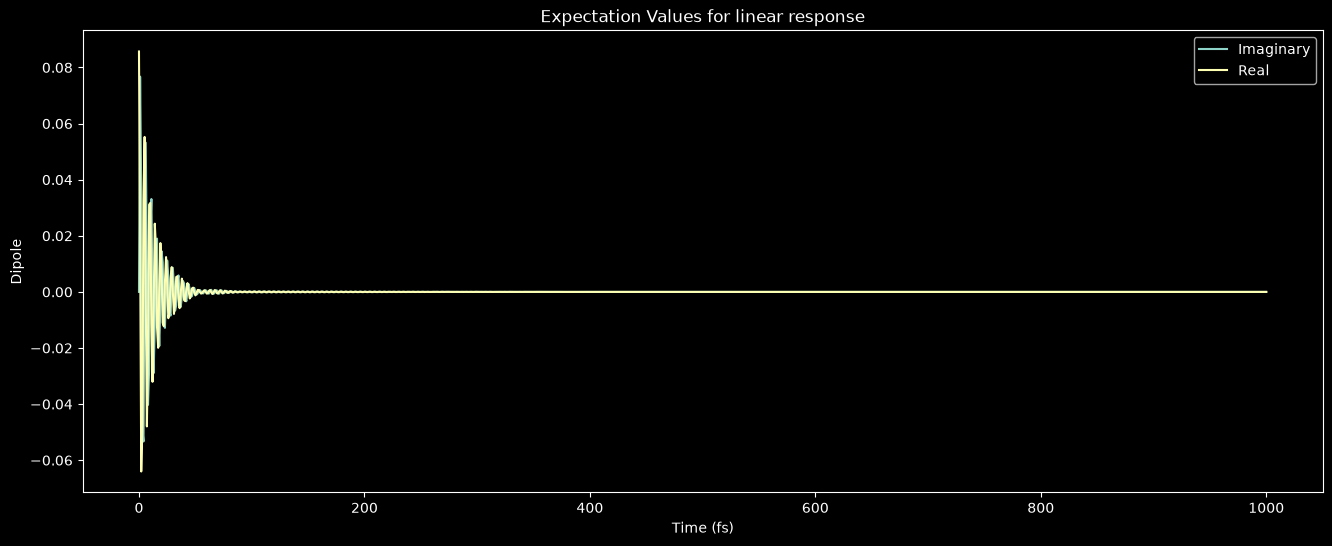

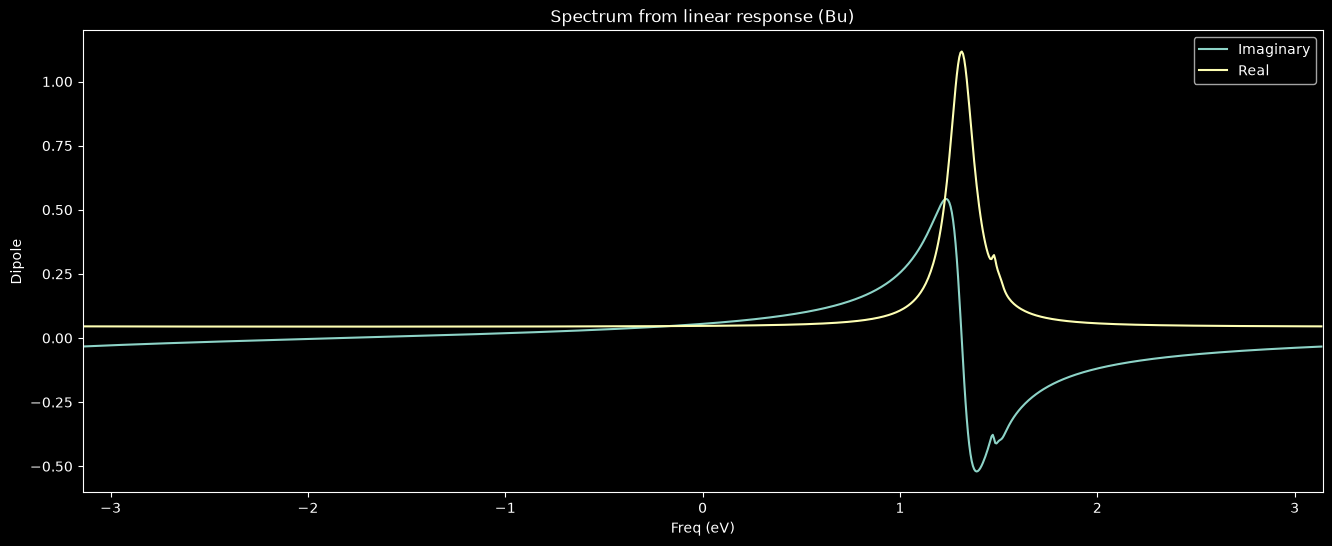

In [8]:
d0 = 1000

dipole, t_list, spec, freq = syst.linear_spec(d0, r=1, dir=directory, title_graph="lindip")

os.makedirs(directory+date+"/"+graph_title, exist_ok=True)

with open(directory+date+"/"+graph_title+"/parameters.txt", "w", encoding="utf-8") as file:
    file.write(hour+"\n")
    file.write(f"N{N}\n")
    file.write(f"Energies  bright={en_b:.4f}, dark={en_d:.4f}, cavity={en_cav:.4f}\n")
    file.write(f"detuning strength={detuning:.4}\n")
    file.write(f"light-matter coupling g={g:.4f}\n")
    file.write(f"bright-dark coupling J={J:.4f}\n")
    file.write(f"dipole strength  bright={mub:.1f}, dark={mud:.1f}, cavity={muc:.1f}\n")
    file.write(f"dephasing  excitons={gamma_exc_phase:.4f}, cavity={gamma_cav_phase:.4f}\n")
    file.write(f"decay  bright={gamma_b_decay:.4f}, dark={gamma_d_decay:.4f}, cavity={kappa:.4f}\n")
    file.write(f"binding energies  bright-bright={bb_bind:.4f}, bright-dark={bd_bind:.4f}, dark-dark={dd_bind:.4f}\n")
    file.write(f"grid size(t1,t3)={grid}")
    file.write(f"population time={t2}")
    file.write(f"model={model}")

with open(directory+date+"/"+graph_title+"/dip.pkl", "wb") as file:
    pickle.dump(dipole, file)
with open(directory+date+"/"+graph_title+"/tlist.pkl", "wb") as file:
    pickle.dump(t_list, file)
with open(directory+date+"/"+graph_title+"/spec.pkl", "wb") as file:
    pickle.dump(spec, file)
with open(directory+date+"/"+graph_title+"/freq.pkl", "wb") as file:
    pickle.dump(freq, file)

#### pickle loading

In [9]:
# with open(directory+date+"/"+graph_title+"/dip.pkl", "rb") as file:
#     dipole = pickle.load(file)
# with open(directory+date+"/"+graph_title+"/tlist.pkl", "rb") as file:
#     t_list = pickle.load(file)
# with open(directory+date+"/"+graph_title+"/spec.pkl", "rb") as file:
#     spec = pickle.load(file)
# with open(directory+date+"/"+graph_title+"/freq.pkl", "rb") as file:
#     freq = pickle.load(file)

### Linear plotting

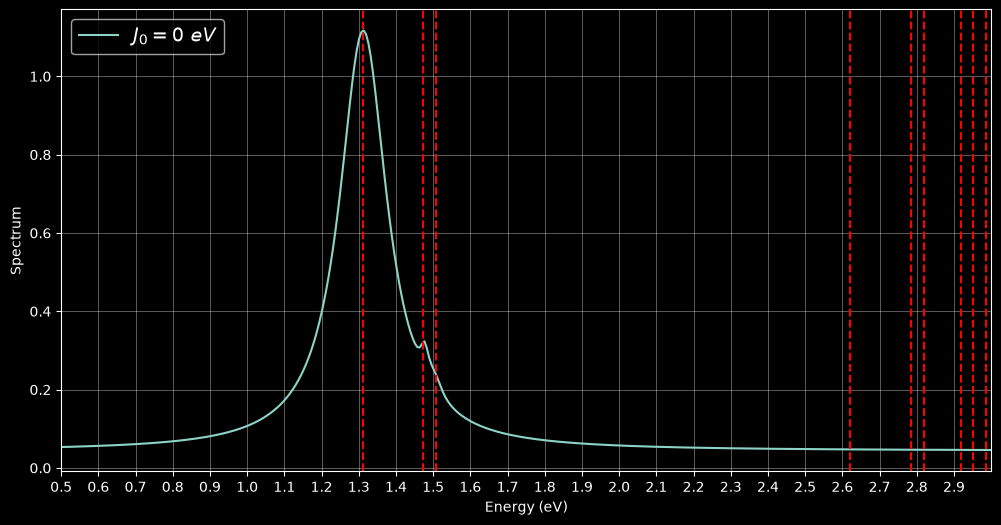

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(t_list, np.real(dipole), label="$J_{0} = 0 \\ eV$")  # real part of the dipole
plt.xlim(0, 80)
plt.xlabel("Time (fs)")
plt.ylabel("Dipole")
plt.legend(fontsize=14)
plt.grid()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(freq, np.real(spec), label="$J_{0} = 0 \\ eV$")  # real part of the spectrum
plt.xlim(0.5, 3.)
plt.xticks(np.arange(0.5, 3., 0.1))
for i in H.eigenenergies():
    plt.axvline(x=i, color='red', linestyle='--')
plt.xlabel("Energy (eV)")
plt.ylabel("Spectrum")
plt.legend(fontsize=14)
plt.grid()
plt.savefig(directory+date+"/"+graph_title+"/linspec.png")
plt.show()

### 3rd order spectra + pickle saving
For time delays, it seems you need at least as many as 1/(weakest coupling) to see the specific features. Weaker couplings means bigger time delays aka longer simulation run time.

In [ ]:
if order==3:
    # Setting up the required double sided diagrams for tests
    # DiagramGenerator class, or DG for short
    DG = ufss.DiagramGenerator
    # initialize the module

    R3rd = DG()  # DG takes a single key-word argument, which has the default value detection_type = 'polarization'
    # DiagramAutomation needs to know the phase-matching/-cycling condition
    R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])  # setting phase-matching condition for rephasing diagrams R1,2,3
    # Set the pulse interval
    t_pulse = np.array([-1, 1])
    R3rd.efield_times = [t_pulse] * 4

    # Creating diagrams for pulse arrival times 0, 120, 240 and detection time 360.
    [R3, R1, R2] = R3rd.get_diagrams([0, 120, 240, 360])
    rephasing = [R1, R2, R3]
    print('the rephasing diagrams are R1, R2 and R3 ', rephasing)

    # setting conditions for and generating non-rephasing diagrams R4, R5 and R6
    R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
    [R6, R4, R5] = R3rd.get_diagrams([0, 120, 240, 240])
    nonrephasing = [R4, R5, R6]
    print('the non-rephasing diagrams are R4, R5 and R6', nonrephasing)

    # syst.diagram_donkey([0, 120, 120+time2, 240+time2], [R3], r=10, title_graph=None, plot_graph=False, dir=directory)

    print("finished setup stage")

    # generating 2Dcoherence response for rephasing diagrams
    time_delays = [grid, t2, grid]
    scan_id = [0, 2]
    response_list = []
    diagrams = rephasing + nonrephasing
    for k in range(6):
        states, t1, t2, dipole = syst.coherence2d(time_delays, diagrams[k], scan_id, r=1, parallel=True)
        print('diagram ', k, ' done')
        response_list.append(1j * dipole)
    spectra_list, extent, f1, f2 = syst.spectra(np.imag(response_list), resolution=1)

    with open(directory+date+"/"+graph_title+"/3rd_spec2d.pkl", "wb") as file:
        pickle.dump(spectra_list, file)
    with open(directory+date+"/"+graph_title+"/3rd_extent.pkl", "wb") as file:
        pickle.dump(extent, file)
    with open(directory+date+"/"+graph_title+"/3rd_f1.pkl", "wb") as file:
        pickle.dump(f1, file)
    with open(directory+date+"/"+graph_title+"/3rd_f2.pkl", "wb") as file:
        pickle.dump(f2, file)

the rephasing diagrams are R1, R2 and R3  [(('Bu', 0), ('Ku', 1), ('Bd', 2)), (('Bu', 0), ('Bd', 1), ('Ku', 2)), (('Bu', 0), ('Ku', 1), ('Ku', 2))]
the non-rephasing diagrams are R4, R5 and R6 [(('Ku', 0), ('Bu', 1), ('Ku', 2)), (('Ku', 0), ('Bu', 1), ('Bd', 2)), (('Ku', 0), ('Kd', 1), ('Ku', 2))]
finished setup stage
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors


 58%|█████▊    | 174/300 [11:47<06:15,  2.98s/it]

#### pickle loading

In [ ]:
# if order==3:
    # with open(directory+date+"/"+graph_title+"/3rd_spec2d.pkl", "rb") as file:
    #     spec2d = pickle.load(file)
    # with open(directory+date+"/"+graph_title+"/3rd_extent.pkl", "rb") as file:
    #     extent = pickle.load(file)
    # with open(directory+date+"/"+graph_title+"/3rd_f1.pkl", "rb") as file:
    #     f1 = pickle.load(file)
    # with open(directory+date+"/"+graph_title+"/3rd_f2.pkl", "rb") as file:
    #     f2 = pickle.load(file)

#### 3rd order plotting

In [ ]:
levels = [25, 50, 100]
if order==3:
    rephasing_spectra = spectra_list[:3]
    rephasing_spectra.append(np.sum(spectra_list[:3], 0))
    for i in levels:
        pf.silva_plot_contourf(rephasing_spectra, f1, f2, labels=['E emission', 'E absorption'],
                  scale='linear', color_map='PuOr', title_list = ['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'],
                  center_scale=False, plot_sum=False, plot_quadrant='Zoom', zoom_coor=[-1.8,-1.2,1.2,1.8],
                  invert_y=False, diagonals=[True, False], nlevels=i,
                  title_graph=f"2d_spectra_n{i}", plot_graph=True, direc=directory+date+"/"+graph_title+"/")